Libraries

In [1170]:
import numpy as np
import matplotlib.pyplot as plt
import cv2


Edge Detection


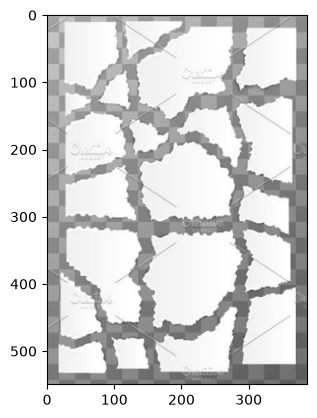

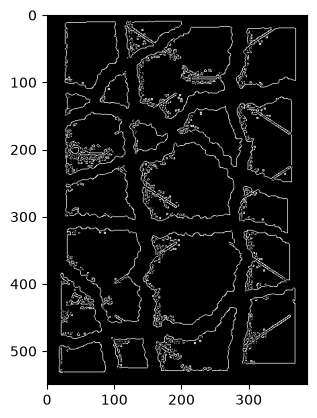

In [1171]:
image_path = r'D:\PythonProject1\Intern\Images\img111.png'
image = cv2.imread(image_path)
gray_image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
blurred = cv2.GaussianBlur(gray_image, (3,3), 0)
_, thresh = cv2.threshold(gray_image, 240, 245, cv2.THRESH_BINARY_INV)
canny = cv2.Canny(thresh,50,150)
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.show()
plt.imshow(canny, cmap='gray')
plt.show()

Seperate Each Torn Fragment using Contours

In [1172]:
_, thresh = cv2.threshold(blurred, 200, 255, cv2.THRESH_BINARY) 

kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (5, 5))
closed = cv2.morphologyEx(thresh, cv2.MORPH_CLOSE, kernel)
contours, hierarchy = cv2.findContours(closed, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
min_area = 500 
valid_contours = [c for c in contours if cv2.contourArea(c) > min_area]
contour_img = image.copy()
cv2.drawContours(contour_img, valid_contours, -1, (0, 255, 0), 3)


array([[[199, 199, 199],
        [199, 199, 199],
        [199, 199, 199],
        ...,
        [169, 169, 169],
        [166, 166, 166],
        [166, 166, 166]],

       [[205, 205, 205],
        [205, 205, 205],
        [204, 204, 204],
        ...,
        [167, 167, 167],
        [167, 167, 167],
        [168, 168, 168]],

       [[182, 182, 182],
        [181, 181, 181],
        [180, 180, 180],
        ...,
        [151, 151, 151],
        [148, 148, 148],
        [149, 149, 149]],

       ...,

       [[147, 147, 147],
        [147, 147, 147],
        [147, 147, 147],
        ...,
        [111, 111, 111],
        [110, 110, 110],
        [110, 110, 110]],

       [[146, 146, 146],
        [146, 146, 146],
        [146, 146, 146],
        ...,
        [110, 110, 110],
        [110, 110, 110],
        [110, 110, 110]],

       [[146, 146, 146],
        [146, 146, 146],
        [146, 146, 146],
        ...,
        [110, 110, 110],
        [110, 110, 110],
        [110, 110, 110]]

In [1173]:
isolated_pieces_list = []  
count=0
for contour in valid_contours: 
    x, y, w, h = cv2.boundingRect(contour)
    pad =0
    
    x_start, x_end = max(0, x - pad), min(image.shape[1], x + w + pad)
    y_start, y_end = max(0, y - pad), min(image.shape[0], y + h + pad)
    
    cropped_piece = image[y_start:y_end, x_start:x_end]
    
    mask = np.zeros_like(closed)
    cv2.drawContours(mask, [contour], -1, 255, -1) 

    cropped_mask = mask[y_start:y_end, x_start:x_end]
    
    isolated_piece = cv2.bitwise_and(cropped_piece, cropped_piece, mask=cropped_mask)
    
    rgb_piece = cv2.cvtColor(isolated_piece, cv2.COLOR_BGR2RGB)
    isolated_pieces_list.append(rgb_piece)
    count += 1
    # plt.imshow(rgb_piece)
    # plt.show()

Add padding on Border

In [1174]:
cc=0
for i in isolated_pieces_list:
    if count==cc:
        break
    else:
        top,bottom,left,right=10,10,10,10
        padding_color = [0,0,0]
        vertical = cv2.copyMakeBorder(i,0, 0,left,right,borderType=cv2.BORDER_CONSTANT,value=padding_color)
        horizontal=cv2.copyMakeBorder(i,top,bottom,0,0,borderType=cv2.BORDER_CONSTANT,value=padding_color)
        image =vertical


        if len(image.shape) == 3:
            gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
        else:
            gray = image
        _, thresh = cv2.threshold(gray, 15, 255, cv2.THRESH_BINARY)

        points = cv2.findNonZero(thresh)
        x, y, w, h = cv2.boundingRect(points)
        img_height = thresh.shape[0]
        tol = 3
        top = []
        bottom = []

        for col in range(x, x + w):
            white_pixels = np.where(thresh[:, col] == 255)[0]
            if len(white_pixels) > 0:
                actual_top_edge = white_pixels[0]
                top.append(actual_top_edge - y)
                
                actual_bottom_edge = white_pixels[-1]
                absolute_bottom_peak = y + h
                bottom.append(absolute_bottom_peak - actual_bottom_edge)
        avg1_top_deviation = np.mean(top) if top else 0
        avg1_bottom_deviation = np.mean(absolute_bottom_peak) if bottom else 0

        top1_is_torn = avg1_top_deviation > tol or avg1_top_deviation<0
        bottom1_is_torn = avg1_bottom_deviation > tol or avg1_bottom_deviation<0

        image=horizontal
        for col in range(y, y + h):
            white_pixels = np.where(thresh[col:,] == 255)[0]
            if len(white_pixels) > 0:
                actual_top_edge = white_pixels[0]
                top.append(actual_top_edge - x)
                
                actual_bottom_edge = white_pixels[-1]
                absolute_bottom_peak = x + w
                bottom.append(absolute_bottom_peak - actual_bottom_edge)

        avg_top_deviation = np.mean(top) if top else 0
        avg_bottom_deviation = np.mean(bottom) if bottom else 0

        top_is_torn = avg_top_deviation > tol or avg_top_deviation <0
        bottom_is_torn = avg_bottom_deviation > tol or avg_bottom_deviation<0


        # print(f"left Side:   {'TORN' if top_is_torn else 'STRAIGHT '} (Avg : {avg_top_deviation:.2f}px)")
        # print(f"right Side:  {'TORN' if bottom_is_torn else 'STRAIGHT'} (Avg {avg_bottom_deviation:.2f}px)")
        # print(f"Top Side:    {'TORN' if top1_is_torn else 'STRAIGHT'} (Avg {avg1_top_deviation:.2f}px)")
        # print(f"Bottom Side: {'TORN' if bottom1_is_torn else 'STRAIGHT'} (Avg  {avg1_bottom_deviation:.2f}px)")
        
        cc+=1
        
        # plt.imshow(vertical)

        # plt.show()
        # plt.imshow(horizontal)

        # plt.show()

                


Finding Peak

In [1175]:
img = isolated_pieces_list[0]

gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
_, thresh = cv2.threshold(gray, 15, 255, cv2.THRESH_BINARY)
y, x = np.where(thresh == 255)
highest = np.argmax(x)
peak_x = x[highest]
peak_y = y[highest]
output_img = cv2.cvtColor(img, cv2.COLOR_GRAY2BGR) if len(img.shape) == 2 else img.copy()
cv2.circle(output_img, (peak_x, peak_y), 0, (0,0,255), -1)
# plt.imshow(cv2.cvtColor(output_img, cv2.COLOR_BGR2RGB))
# plt.show()
# print(peak_y)
# print(peak_x)

array([[[  0,   0,   0],
        [  0,   0,   0],
        [  0,   0,   0],
        ...,
        [  0,   0,   0],
        [  0,   0,   0],
        [  0,   0,   0]],

       [[  0,   0,   0],
        [  0,   0,   0],
        [  0,   0,   0],
        ...,
        [  0,   0,   0],
        [  0,   0,   0],
        [  0,   0,   0]],

       [[  0,   0,   0],
        [  0,   0,   0],
        [  0,   0,   0],
        ...,
        [  0,   0,   0],
        [  0,   0,   0],
        [  0,   0,   0]],

       ...,

       [[234, 234, 234],
        [244, 244, 244],
        [240, 240, 240],
        ...,
        [239, 239, 239],
        [  0,   0,   0],
        [  0,   0,   0]],

       [[238, 238, 238],
        [248, 248, 248],
        [243, 243, 243],
        ...,
        [216, 216, 216],
        [  0,   0,   0],
        [  0,   0,   0]],

       [[  0,   0,   0],
        [  0,   0,   0],
        [  0,   0,   0],
        ...,
        [  0,   0,   0],
        [  0,   0,   0],
        [  0,   0,   0]]

Add padding using peak

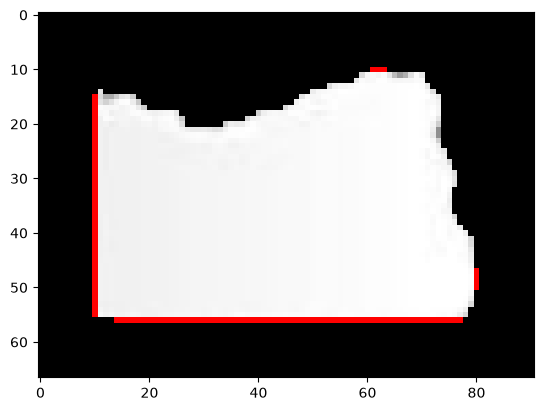

In [1176]:
bottom = np.max(y)  
right = np.max(x)  
top= np.min(y) 
left = np.min(x)  
output= cv2.cvtColor(img, cv2.COLOR_GRAY2BGR) if len(img.shape) == 2 else img.copy()
output = cv2.copyMakeBorder(output,10,10,10,10,borderType=cv2.BORDER_CONSTANT,value=padding_color)

bottom += 10
right += 10
top += 10
left += 10
y1 = x[y == (bottom-10)]+10
for peak_y in y1:
    cv2.circle(output, (peak_y, bottom), 0, (0, 0, 255), -1)
    # print(peak_y, bottom)

y2 = y[x == right-10]+10 
for peak_y in y2:
    cv2.circle(output, (right, peak_y), 0, (0, 0, 255), -1) 
    #print(x2,peak_y)

y3 = x[y == top-10]+10 
for peak_y in y3:
    cv2.circle(output, (peak_y, top), 0, (0, 0, 255), -1)
    #print(peak_y, x3)
y4 = y[x == left-10]+10 
for peak_y in y4:
    cv2.circle(output, (left, peak_y), 0, (0, 0, 255), -1)
plt.imshow(cv2.cvtColor(output, cv2.COLOR_BGR2RGB))
plt.show()



In [1177]:

# ver=output.copy()

# g1= 5
# b1=(left , top - g1)
# b2=(right , bottom + g1)

# cv2.rectangle(ver, b1, b2, (255, 255, 255), 1)

# plt.imshow(cv2.cvtColor(ver, cv2.COLOR_BGR2RGB))
# plt.show()
# hor=output.copy()

# b1=(left - g1, top )
# b2=(right + g1, bottom )

# cv2.rectangle(hor, b1, b2, (255, 255, 255), 1)

# plt.imshow(cv2.cvtColor(hor, cv2.COLOR_BGR2RGB))
# plt.show()

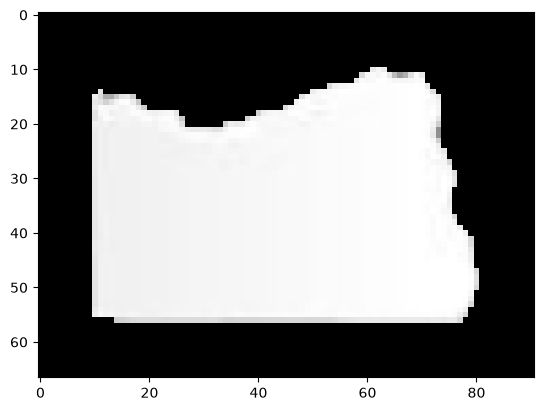

In [1178]:
img=isolated_pieces_list[0]
img = cv2.copyMakeBorder(img,10,10,10,10,borderType=cv2.BORDER_CONSTANT,value=padding_color)
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.show()

[(9, 16), (10, 14), (11, 14), (12, 14), (13, 14), (14, 14), (15, 14), (16, 14), (17, 15), (18, 15), (19, 16), (20, 17), (21, 17), (22, 17), (23, 17), (24, 17), (25, 18), (26, 18), (27, 20), (28, 20), (29, 20), (30, 20), (31, 20), (32, 20), (33, 20), (34, 20), (35, 19), (36, 19), (37, 19), (38, 19), (39, 18), (40, 18), (41, 17), (42, 17), (43, 17), (44, 17), (45, 17), (46, 16), (47, 15), (48, 15), (49, 14), (50, 14), (51, 13), (52, 13), (53, 13), (54, 12), (55, 12), (56, 12), (57, 12), (58, 11), (59, 11), (60, 10), (61, 10), (62, 9), (63, 10), (64, 10), (65, 10), (66, 10), (67, 10), (68, 10), (69, 10), (70, 11), (71, 12), (72, 13), (73, 14), (74, 24), (75, 26), (76, 28), (77, 38), (78, 39), (79, 40), (80, 46)]


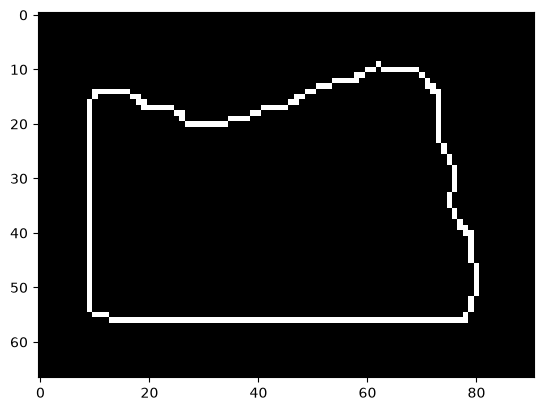

In [1179]:
_, img = cv2.threshold(img, 15, 255, cv2.THRESH_BINARY)
a1=cv2.Canny(img,150,150)
y_arr, x_arr = np.where(a1 == 255)

left = np.min(x_arr)
right = np.max(x_arr)
b11= []
for col_x in range(left, right + 1):
    pixels_in_col = y_arr[x_arr == col_x]
    
    if len(pixels_in_col) > 0:
        top_y = np.min(pixels_in_col)
        
        b11.append((int(col_x), int(top_y)))
print(b11)
plt.imshow(cv2.cvtColor(a1, cv2.COLOR_BGR2RGB))
plt.show()

In [1180]:
a2 = cv2.copyMakeBorder(thresh,10,10,10,10,borderType=cv2.BORDER_CONSTANT,value=padding_color)
g1= 5
b1=(left , top - g1)
b2=(right , bottom + g1)

cv2.rectangle(a2, b1, b2, (255, 255, 255), 1)

# plt.imshow(cv2.cvtColor(a2, cv2.COLOR_BGR2RGB))
# plt.show()

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], shape=(67, 91), dtype=uint8)

[(9, 5), (10, 5), (11, 5), (12, 5), (13, 5), (14, 5), (15, 5), (16, 5), (17, 5), (18, 5), (19, 5), (20, 5), (21, 5), (22, 5), (23, 5), (24, 5), (25, 5), (26, 5), (27, 5), (28, 5), (29, 5), (30, 5), (31, 5), (32, 5), (33, 5), (34, 5), (35, 5), (36, 5), (37, 5), (38, 5), (39, 5), (40, 5), (41, 5), (42, 5), (43, 5), (44, 5), (45, 5), (46, 5), (47, 5), (48, 5), (49, 5), (50, 5), (51, 5), (52, 5), (53, 5), (54, 5), (55, 5), (56, 5), (57, 5), (58, 5), (59, 5), (60, 5), (61, 5), (62, 5), (63, 5), (64, 5), (65, 5), (66, 5), (67, 5), (68, 5), (69, 5), (70, 5), (71, 5), (72, 5), (73, 5), (74, 5), (75, 5), (76, 5), (77, 5), (78, 5), (79, 5), (80, 5)]


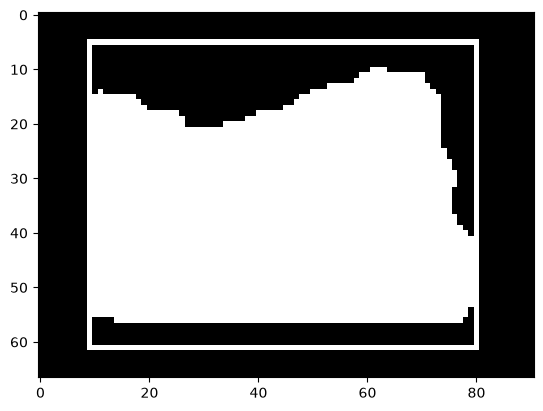

In [1181]:
y_arr, x_arr = np.where(a2 == 255)

left = np.min(x_arr)
right = np.max(x_arr)
b22 = []
for col_x in range(left, right + 1):
    pixels_in_col = y_arr[x_arr == col_x]
    
    if len(pixels_in_col) > 0:
        top_y = np.min(pixels_in_col)
        
        b22.append((int(col_x), int(top_y)))
print(b22)
plt.imshow(cv2.cvtColor(a2, cv2.COLOR_BGR2RGB))
plt.show()

In [1182]:
distances = [int(y11) - int(y22) for (_, y11), (_, y22) in zip(b11, b22)]
print(b11)
print(b22)
print(distances)

[(9, 16), (10, 14), (11, 14), (12, 14), (13, 14), (14, 14), (15, 14), (16, 14), (17, 15), (18, 15), (19, 16), (20, 17), (21, 17), (22, 17), (23, 17), (24, 17), (25, 18), (26, 18), (27, 20), (28, 20), (29, 20), (30, 20), (31, 20), (32, 20), (33, 20), (34, 20), (35, 19), (36, 19), (37, 19), (38, 19), (39, 18), (40, 18), (41, 17), (42, 17), (43, 17), (44, 17), (45, 17), (46, 16), (47, 15), (48, 15), (49, 14), (50, 14), (51, 13), (52, 13), (53, 13), (54, 12), (55, 12), (56, 12), (57, 12), (58, 11), (59, 11), (60, 10), (61, 10), (62, 9), (63, 10), (64, 10), (65, 10), (66, 10), (67, 10), (68, 10), (69, 10), (70, 11), (71, 12), (72, 13), (73, 14), (74, 24), (75, 26), (76, 28), (77, 38), (78, 39), (79, 40), (80, 46)]
[(9, 5), (10, 5), (11, 5), (12, 5), (13, 5), (14, 5), (15, 5), (16, 5), (17, 5), (18, 5), (19, 5), (20, 5), (21, 5), (22, 5), (23, 5), (24, 5), (25, 5), (26, 5), (27, 5), (28, 5), (29, 5), (30, 5), (31, 5), (32, 5), (33, 5), (34, 5), (35, 5), (36, 5), (37, 5), (38, 5), (39, 5), (4

In [1183]:
i = isolated_pieces_list[0]
padded_image = cv2.copyMakeBorder(i, 10, 10, 10, 10, borderType=cv2.BORDER_CONSTANT, value=[0,0,0])
gray = cv2.cvtColor(padded_image, cv2.COLOR_BGR2GRAY)
_, thresh = cv2.threshold(gray, 15, 255, cv2.THRESH_BINARY)
points = cv2.findNonZero(thresh)
x, y, w, h = cv2.boundingRect(points)

tol = 3
top_deviations = []
bottom_deviations = []

for col in range(x, x + w):
    white_pixels = np.where(thresh[:, col] == 255)[0]
    if len(white_pixels) > 0:
        actual_top_edge = white_pixels[0]
        top_deviations.append(int(actual_top_edge - y))
                
        actual_bottom_edge = white_pixels[-1]
        absolute_bottom_peak = y + h
        bottom_deviations.append(int(absolute_bottom_peak - actual_bottom_edge))

avg1_top_deviation = np.mean(top_deviations) if top_deviations else 0
avg1_bottom_deviation = np.mean(bottom_deviations) if bottom_deviations else 0

top1_is_torn = avg1_top_deviation > tol
bottom1_is_torn = avg1_bottom_deviation > tol

print(f"Top :    {'TORN' if top1_is_torn else 'STRAIGHT'} (Avg : {avg1_top_deviation:.2f}px)")
print(f"Bottom : {'TORN' if bottom1_is_torn else 'STRAIGHT'} (Avg : {avg1_bottom_deviation:.2f}px)")

Top :    TORN (Avg : 7.63px)
Bottom : STRAIGHT (Avg : 1.20px)
